# Introduction:

This project contains a supervised machine learning pipeline for predicting the quality of a police–civilian interaction, represented by a continuous target variable called `interaction_score`.

The dataset contains synthetic records of bodycam-recorded encounters, with features describing subject state, officer behavior, situational context, and interaction outcomes. The target variable is defined on a 0–100 scale, where lower values correspond to poorer outcomes and higher values correspond to better-managed interactions.

The main goal is to build and evaluate a regression pipeline that can estimate interaction quality from observable features, while also identifying which variables are most influential in shaping the predicted outcome.

# Importing necessary libraries:

In [1]:
import pandas as pd
import numpy as np
import itertools
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from scipy.stats import randint, uniform, loguniform
from pathlib import Path

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (FunctionTransformer, RobustScaler, 
StandardScaler, OneHotEncoder, OrdinalEncoder)
from sklearn.model_selection import (train_test_split, KFold, 
RepeatedKFold, RandomizedSearchCV, cross_validate, learning_curve,
validation_curve, cross_val_score, cross_val_predict)
#why not stratifiedkfold?

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
root_mean_squared_error, r2_score, make_scorer)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

warnings.filterwarnings("ignore")

# Dataset overview:

The dataset contains 5,000 interaction records and 16 columns. Each row represents a single encounter, while the columns describe characteristics of the subject, the officer response, and the situational context.

Before performing preprocessing, we first inspect the dataset shape, preview the first rows, review column names, and examine data types.

In [2]:
df = pd.read_csv(r'C:\Users\romol\Downloads\bodycam_interactions_dataset.csv')

In [3]:
print("Shape:", df.shape)
display(df.head())

Shape: (5000, 16)


,suspect_age,suspect_gender,suspected_offense_type,intoxication_level,mental_confusion_level,suspect_aggression_level,suspect_compliance,officer_tone,officer_deescalation_attempts,bystanders_present,environment_risk_level,time_of_day,number_of_officers,force_used_level,interaction_duration_minutes,interaction_score
0,36,male,public_intoxication,2,0,3,0,1,2,1,1,evening,2,2,23.0,46.9
1,19,male,traffic_violation,1,0,0,2,0,1,0,2,late_night,2,0,10.0,90.2
2,46,female,mental health crisis,1,2,0,0,1,5,0,2,night,3,0,33.0,61.0
3,23,male,suspicious_person,1,1,2,2,2,4,1,3,night,3,1,16.0,64.2
4,80,female,domestic_disturbance,0,1,2,0,3,4,1,2,evening,3,2,18.0,53.5


In [4]:
print("\nColumns:")
print(df.columns.tolist())


Columns:
['suspect_age', 'suspect_gender', 'suspected_offense_type', 'intoxication_level', 'mental_confusion_level', 'suspect_aggression_level', 'suspect_compliance', 'officer_tone', 'officer_deescalation_attempts', 'bystanders_present', 'environment_risk_level', 'time_of_day', 'number_of_officers', 'force_used_level', 'interaction_duration_minutes', 'interaction_score']


The dataset was designed to include imperfections, thus the next step is to inspect missing values and duplicate records.

We therefore standardize common missing-value markers, summarize missingness per feature, visualize the missing-value structure, and count duplicated rows before continuing.

In [5]:
missing_markers = ["", " ", "NA", "N/A", "na", "null", "None"]

In [6]:
df = df.replace(missing_markers, np.nan)

In [7]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({"missing_count": missing_counts,
                                "missing_pct": missing_pct})

display(missing_summary[missing_summary["missing_count"] > 0])

,missing_count,missing_pct
suspect_age,154,3.08
interaction_duration_minutes,148,2.96
time_of_day,139,2.78
suspected_offense_type,100,2.00
suspect_gender,53,1.06


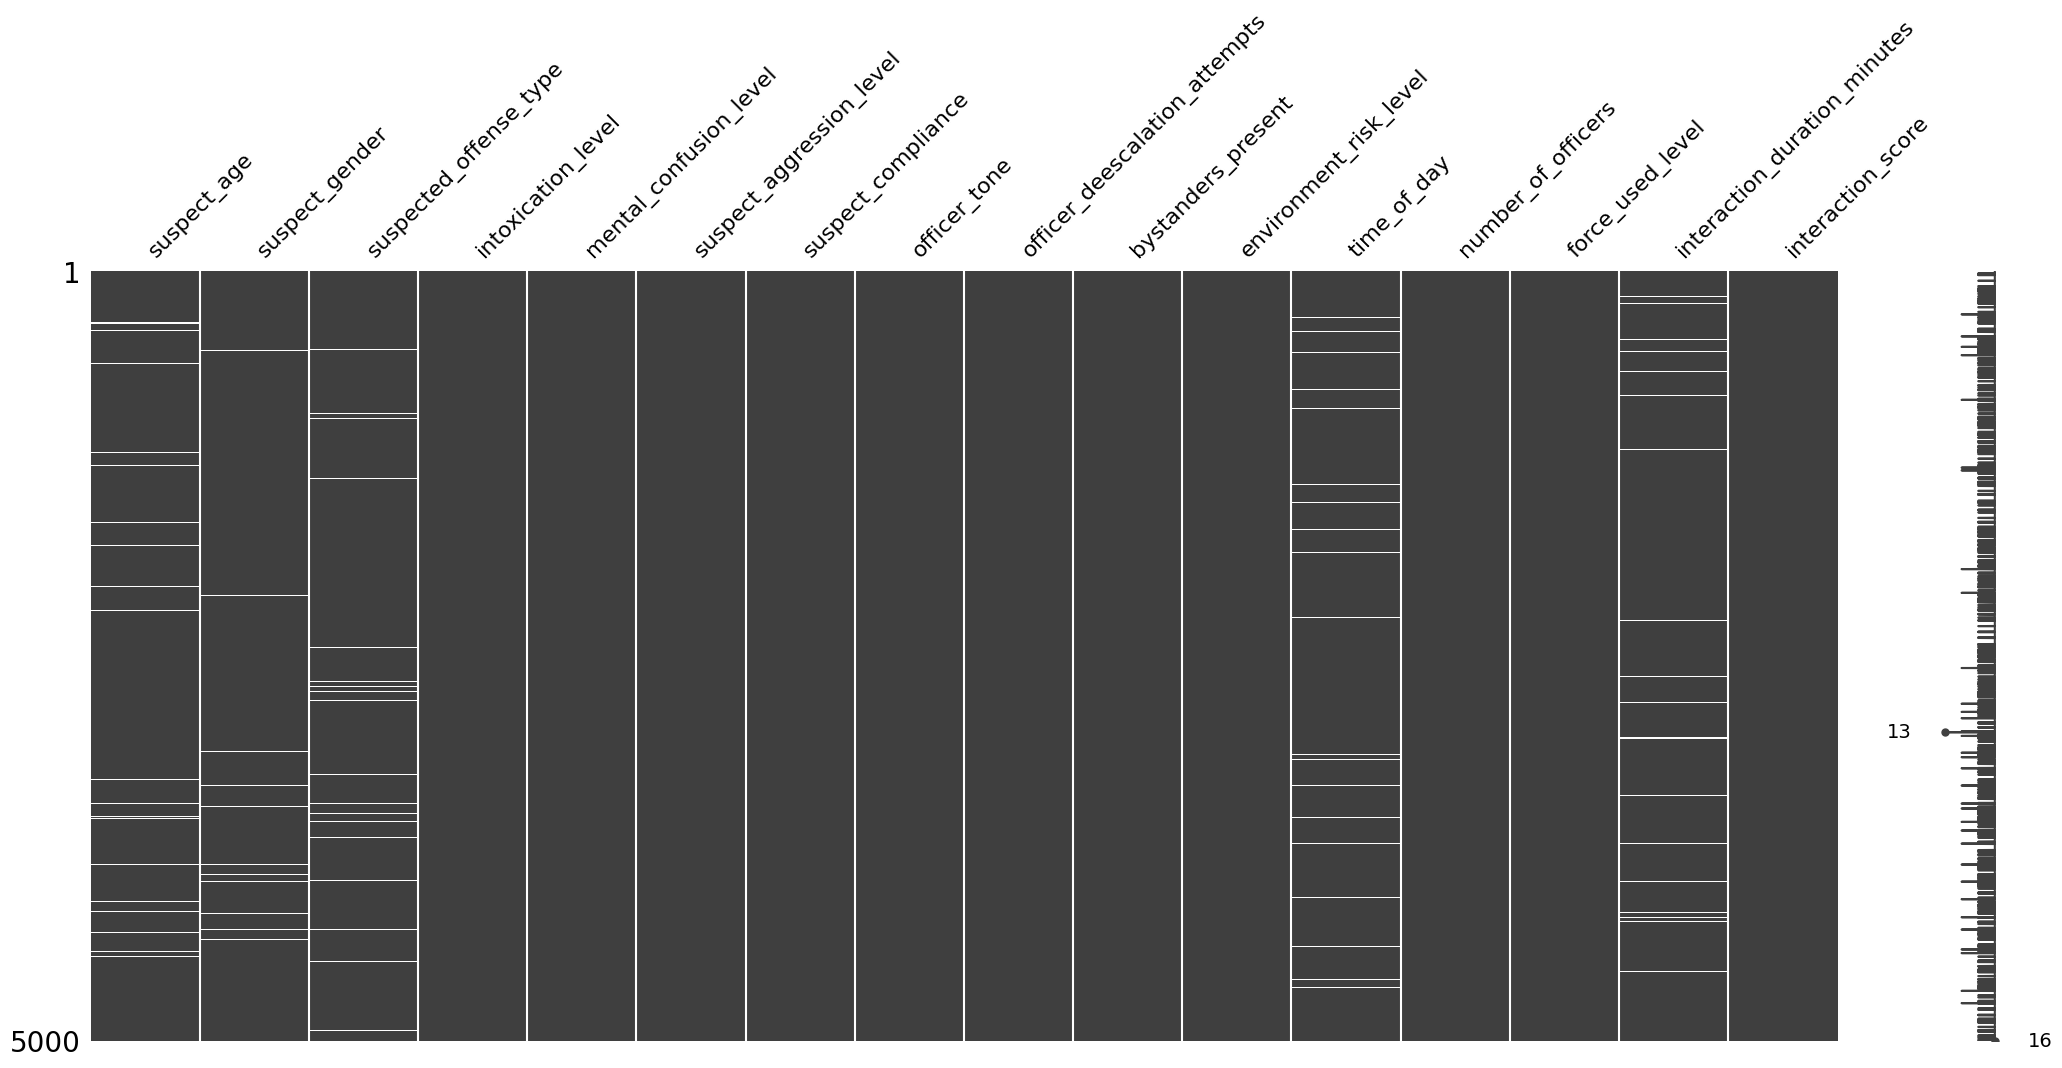

In [8]:
msno.matrix(df)
plt.show()

In [9]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 44


The target variable in this project is `interaction_score`, a continuous measure of interaction quality. Since this is a regression task, understanding the distribution of the target is an important first step.

We visualize the score distribution with a histogram and boxplot in order to inspect its range, central tendency, and potential outliers. This also helps verify that the target behaves as expected before any modeling decisions are made.

In [10]:
df["interaction_score"].describe()

count    5000.000000
mean       66.992080
std        22.133705
min        -3.000000
25%        51.600000
50%        68.700000
75%        84.500000
max       119.500000
Name: interaction_score, dtype: float64

In [11]:
df["interaction_score"] = df["interaction_score"].clip(0, 100)

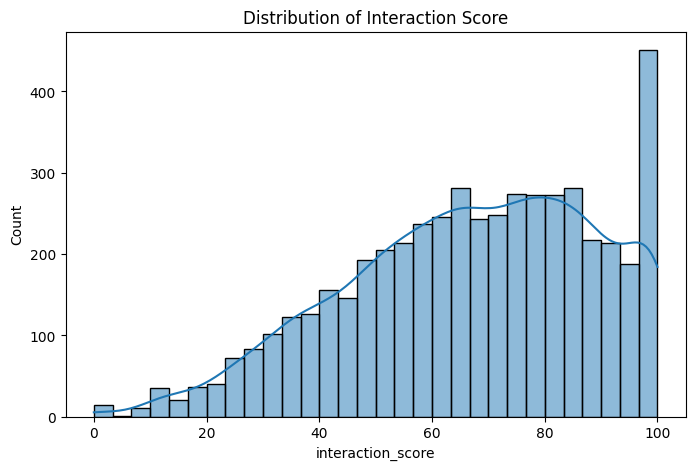

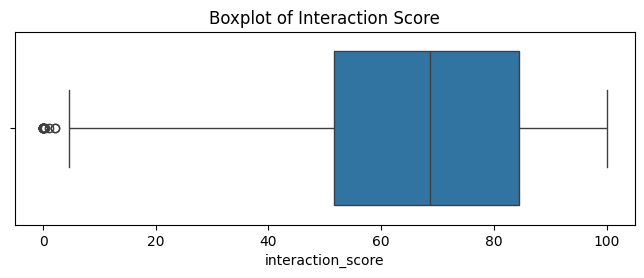

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df["interaction_score"], bins=30, kde=True)
plt.title("Distribution of Interaction Score")
plt.xlabel("interaction_score")
plt.ylabel("Count")
plt.show()
plt.figure(figsize=(8, 2.5))
sns.boxplot(x=df["interaction_score"])
plt.title("Boxplot of Interaction Score")
plt.show()

# Data types + feature overview:

We inspect the data types of all variables to guide preprocessing choices. Some features are already numerical, while others are stored as text and need to be cleaned or converted. To support later preprocessing, we also separate the dataset into numerical and categorical columns. This gives an initial view of the feature space and helps determine which transformations will be needed for each variable type.

In [13]:
print("\nDtypes:")
display(df.dtypes)


Dtypes:


suspect_age                       object
suspect_gender                    object
suspected_offense_type            object
intoxication_level                 int64
mental_confusion_level             int64
suspect_aggression_level           int64
suspect_compliance                 int64
officer_tone                       int64
officer_deescalation_attempts      int64
bystanders_present                 int64
environment_risk_level             int64
time_of_day                       object
number_of_officers                 int64
force_used_level                   int64
interaction_duration_minutes     float64
interaction_score                float64
dtype: object

In [14]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['intoxication_level', 'mental_confusion_level', 'suspect_aggression_level', 'suspect_compliance', 'officer_tone', 'officer_deescalation_attempts', 'bystanders_present', 'environment_risk_level', 'number_of_officers', 'force_used_level', 'interaction_duration_minutes', 'interaction_score']
Categorical columns: ['suspect_age', 'suspect_gender', 'suspected_offense_type', 'time_of_day']


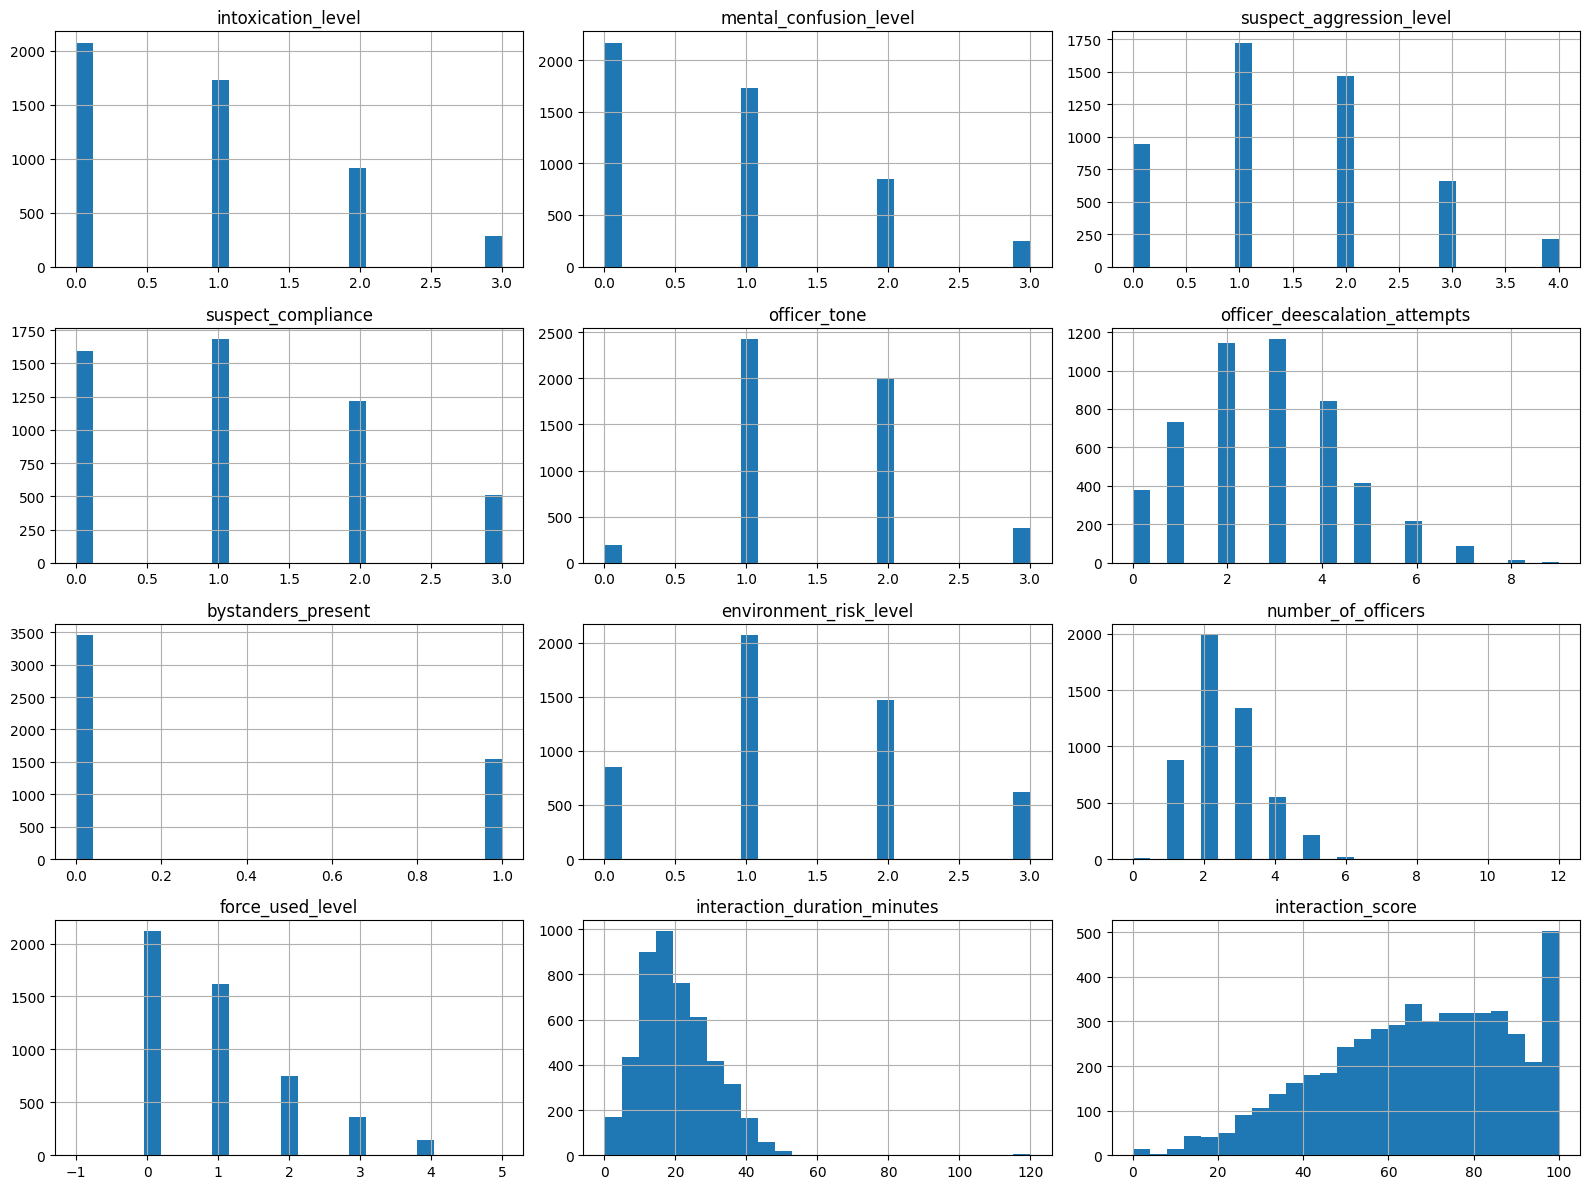

In [15]:
df[num_cols].hist(figsize=(16, 12), bins=25)
plt.tight_layout()
plt.show()

Before standardizing category labels, we inspect the unique values of the categorical variables to reveal inconsistent capitalization, whitespace, alternative spellings, and duplicate category names that would otherwise create unnecessary feature fragmentation during encoding.

In [16]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

In [17]:
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].dropna().unique()[:20])


suspect_age:
['36' '19' '46' '23' '80' '18' '35' '24' '30' '26' '16' '20' '55' '21'
 '25' '42' '44' '40' '31' '33']

suspect_gender:
['male' 'female' 'unknown' 'M' 'Male' 'Female' 'Unknown' 'F']

suspected_offense_type:
['public_intoxication' 'traffic_violation' 'mental health crisis'
 'suspicious_person' 'domestic_disturbance' 'DUI' 'violent_crime'
 'mental_health_crisis' 'warrant' 'other' 'retail_theft' 'theft'
 'shoplifting' 'behavioral_health_crisis' 'public intox' 'violent crime'
 'active_warrant' 'assault/violent_crime' 'drunk_driving'
 'suspicious person']

time_of_day:
['evening' 'late_night' 'night' 'day' 'DAY' 'LateNight' 'Evening' 'NIGHT'
 'Night' 'EVENING' 'late night' 'Day']


To preserve the original imported dataset, we create a cleaned working copy called `df_clean`. All subsequent cleaning and modeling steps are performed on this copy.

In [18]:
df_clean = df.copy()

Some variables in the dataset are only fully observable once an interaction has concluded. These variables are informative in retrospective analysis, but they may not be appropriate for a real-time support system.

In [19]:
leaky_features = [
    "force_used_level",
    "interaction_duration_minutes",
    "officer_deescalation_attempts"]

In [20]:
df_clean.drop(columns=leaky_features)

,suspect_age,suspect_gender,suspected_offense_type,intoxication_level,mental_confusion_level,suspect_aggression_level,suspect_compliance,officer_tone,bystanders_present,environment_risk_level,time_of_day,number_of_officers,interaction_score
0,36,male,public_intoxication,2,0,3,0,1,1,1,evening,2,46.9
1,19,male,traffic_violation,1,0,0,2,0,0,2,late_night,2,90.2
2,46,female,mental health crisis,1,2,0,0,1,0,2,night,3,61.0
3,23,male,suspicious_person,1,1,2,2,2,1,3,night,3,64.2
4,80,female,domestic_disturbance,0,1,2,0,3,1,2,evening,3,53.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,36,male,suspicious_person,2,1,1,2,2,1,2,late_night,4,80.4
4996,47,male,domestic_disturbance,1,2,2,1,2,1,2,day,4,53.8
4997,25,male,public_intoxication,2,2,3,1,2,0,0,Day,3,32.5
4998,41,male,misc,0,0,0,2,1,1,1,night,2,100.0


In [21]:
df_clean["suspect_age"] = pd.to_numeric(df_clean["suspect_age"], errors="coerce")

In [22]:
df_clean["time_of_day"] = (
    df_clean["time_of_day"]
    .str.strip()
    .str.lower()
    .replace({
        "late night": "late_night",
        "latenight": "late_night"}))

In [23]:
df_clean["suspect_gender"] = (df_clean["suspect_gender"]
    .str.strip()
    .str.lower()
    .replace({"m": "male",
        "f": "female"}))

In [24]:
df_clean["suspected_offense_type"] = (
    df_clean["suspected_offense_type"]
    .str.strip()
    .str.lower()
    .replace({"mental health crisis": "mental_health_crisis",
        "behavioral_health_crisis": "mental_health_crisis",
        "public intox": "public_intoxication",
        "violent crime": "violent_crime",
        "assault/violent_crime": "violent_crime",
        "active_warrant": "warrant",
        "drunk_driving": "dui",
        "suspicious person": "suspicious_person",
        "shoplifting": "retail_theft",
        "theft": "retail_theft",
        "trafficviolation": "traffic_violation",
        "traffic stop": "traffic_violation",
        "domestic": "domestic_disturbance",
        "misc": "other"}))

In [25]:
df_clean["suspected_offense_type"] = df_clean["suspected_offense_type"].replace({
    "dui": "DUI", "trafficviolation":"traffic_violation", "domestic":"domestic_disturbance", "traffic stop":"traffic_violation", "misc":"other"})

display(df_clean["suspected_offense_type"].value_counts(dropna=False))

suspected_offense_type
traffic_violation       952
retail_theft            734
DUI                     494
violent_crime           444
suspicious_person       410
other                   408
mental_health_crisis    406
domestic_disturbance    395
public_intoxication     361
warrant                 296
NaN                     100
Name: count, dtype: int64

In [26]:
for col in ["suspect_age", "suspect_gender", "suspected_offense_type", "time_of_day"]:
    print(f"\n{col}:")
    print(df_clean[col].dropna().unique())


suspect_age:
[ 36.  19.  46.  23.  80.  18.  35.  24.  30.  26.  16.  20.  55.  21.
  25.  42.  44.  40.  31.  33.  32.  43.  29.  45.  28.  22.  38.  41.
  50.  39.  37.  34.  17.  27.  47.   7.  48.  56.  52.  54.  49.  51.
   9.  68.  53.  60. 102.  63.  59.  57.  65.  66.  62.  64.  61.  58.
  70.  69.  79.  67.]

suspect_gender:
['male' 'female' 'unknown']

suspected_offense_type:
['public_intoxication' 'traffic_violation' 'mental_health_crisis'
 'suspicious_person' 'domestic_disturbance' 'DUI' 'violent_crime'
 'warrant' 'other' 'retail_theft']

time_of_day:
['evening' 'late_night' 'night' 'day']


In [27]:
print("Cleaned dataset shape:", df_clean.shape)

print("\nMissing values:")
display(df_clean.isna().sum().sort_values(ascending=False))

print("\nCategorical value counts:")
display(df_clean["suspect_gender"].value_counts(dropna=False))
display(df_clean["suspected_offense_type"].value_counts(dropna=False))
display(df_clean["time_of_day"].value_counts(dropna=False))

Cleaned dataset shape: (5000, 16)

Missing values:


suspect_age                      249
interaction_duration_minutes     148
time_of_day                      139
suspected_offense_type           100
suspect_gender                    53
intoxication_level                 0
mental_confusion_level             0
suspect_aggression_level           0
suspect_compliance                 0
officer_tone                       0
officer_deescalation_attempts      0
bystanders_present                 0
environment_risk_level             0
number_of_officers                 0
force_used_level                   0
interaction_score                  0
dtype: int64


Categorical value counts:


suspect_gender
male       3143
female     1572
unknown     232
NaN          53
Name: count, dtype: int64

suspected_offense_type
traffic_violation       952
retail_theft            734
DUI                     494
violent_crime           444
suspicious_person       410
other                   408
mental_health_crisis    406
domestic_disturbance    395
public_intoxication     361
warrant                 296
NaN                     100
Name: count, dtype: int64

time_of_day
day           1495
evening       1280
night         1114
late_night     972
NaN            139
Name: count, dtype: int64

In [28]:
print("Duplicates before:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()
print("Duplicates after:", df_clean.duplicated().sum())
print("Shape:", df_clean.shape)

Duplicates before: 59
Duplicates after: 0
Shape: (4941, 16)


In [29]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
display(df_clean[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
suspect_age,4692.0,32.115303,10.948403,7.0,24.0,32.0,39.0,102.0
intoxication_level,4941.0,0.878769,0.900111,0.0,0.0,1.0,1.0,3.0
mental_confusion_level,4941.0,0.833839,0.881270,0.0,0.0,1.0,1.0,3.0
suspect_aggression_level,4941.0,1.493422,1.069927,0.0,1.0,1.0,2.0,4.0
suspect_compliance,4941.0,1.129933,0.975467,0.0,0.0,1.0,2.0,3.0
officer_tone,4941.0,1.512649,0.689784,0.0,1.0,1.0,2.0,3.0
officer_deescalation_attempts,4941.0,2.807934,1.658784,0.0,2.0,3.0,4.0,9.0
bystanders_present,4941.0,0.307225,0.461390,0.0,0.0,0.0,1.0,1.0
environment_risk_level,4941.0,1.368954,0.904375,0.0,1.0,1.0,2.0,3.0
number_of_officers,4941.0,2.458409,1.088280,0.0,2.0,2.0,3.0,12.0


In [30]:
for col in numeric_cols:
    print(f"\n{col}")
    print("min:", df_clean[col].min(), "max:", df_clean[col].max())


suspect_age
min: 7.0 max: 102.0

intoxication_level
min: 0 max: 3

mental_confusion_level
min: 0 max: 3

suspect_aggression_level
min: 0 max: 4

suspect_compliance
min: 0 max: 3

officer_tone
min: 0 max: 3

officer_deescalation_attempts
min: 0 max: 9

bystanders_present
min: 0 max: 1

environment_risk_level
min: 0 max: 3

number_of_officers
min: 0 max: 12

force_used_level
min: -1 max: 5

interaction_duration_minutes
min: 0.0 max: 120.0

interaction_score
min: 0.0 max: 100.0


In [31]:
df_clean.loc[(df_clean["suspect_age"] < 16) | (df_clean["suspect_age"] > 80), "suspect_age"] = np.nan
df_clean.loc[(df_clean["number_of_officers"] < 1) | (df_clean["number_of_officers"] > 8), "number_of_officers"] = np.nan
df_clean.loc[(df_clean["interaction_duration_minutes"] < 1) | (df_clean["interaction_duration_minutes"] > 60), "interaction_duration_minutes"] = np.nan

After normalization, conversion, and outlier treatment, we recompute the missing-value summary. 
This gives a cleaner picture of what the preprocessing pipeline must handle and confirms that missingness is now represented consistently.

At this stage, remaining missing values are left in place intentionally, since they will be handled within the modeling pipeline using imputation.

In [32]:
missing_summary = pd.DataFrame({"missing_count": df_clean.isna().sum(),
    "missing_pct": df_clean.isna().mean() * 100}).sort_values("missing_count", ascending=False)

display(missing_summary[missing_summary["missing_count"] > 0])

,missing_count,missing_pct
suspect_age,260,5.262093
interaction_duration_minutes,159,3.217972
time_of_day,139,2.813196
suspected_offense_type,100,2.023882
suspect_gender,53,1.072657
number_of_officers,11,0.222627


To support type-specific preprocessing, features are divided into three groups:

- **Numerical features**, like age, interaction duration, and de-escalation counts
- **Ordinal features**, like aggression, compliance, intoxication level, and force level, where ordering is meaningful
- **Nominal features**, like gender, offense type, and time of day, where categories have no natural order

In [33]:
target = "interaction_score"

numeric_features = ["suspect_age","number_of_officers", "bystanders_present"]

ordinal_features = ["intoxication_level","mental_confusion_level",
    "suspect_aggression_level", "suspect_compliance",
    "officer_tone", "environment_risk_level"]

nominal_features = ["suspect_gender", "suspected_offense_type", "time_of_day"]

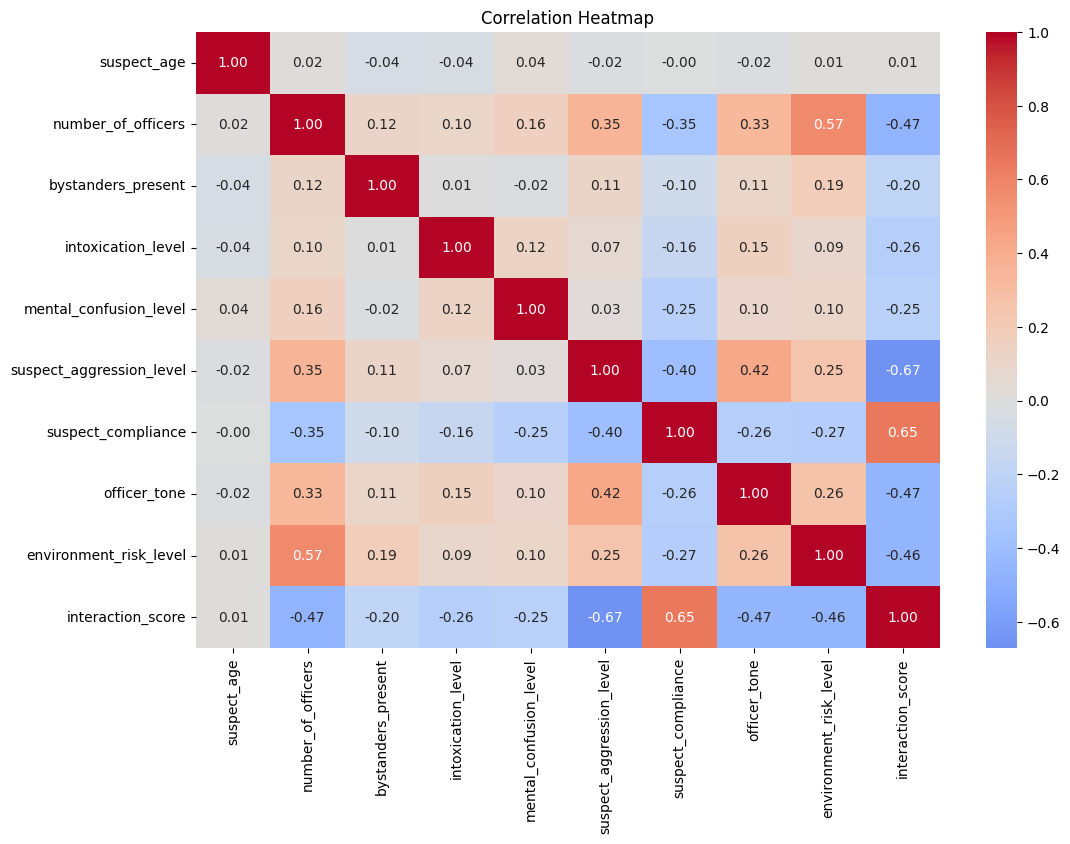

In [34]:
heatmap_cols = numeric_features + ordinal_features + [target]

corr_matrix = df_clean[heatmap_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

We examine correlations among numerical and ordinal features, including the target variable, using a heatmap. This provides an initial view of linear relationships in the cleaned dataset and helps identify strongly associated predictors.

In [35]:
all_features = numeric_features + ordinal_features + nominal_features

print("Total selected features:", len(all_features))
print("Unique selected features:", len(set(all_features)))
print("Duplicate assignments:", len(all_features) != len(set(all_features)))

unused_cols = [col for col in df_clean.columns if col not in all_features + [target]]
print("Unused columns:", unused_cols)

Total selected features: 12
Unique selected features: 12
Duplicate assignments: False
Unused columns: ['officer_deescalation_attempts', 'force_used_level', 'interaction_duration_minutes']


# Preprocessing pipelines:

We define preprocessing pipelines and combine them into a single `ColumnTransformer`.

- Numerical variables are imputed using the median and scaled using `StandardScaler`
- Ordinal variables are imputed and passed through in ordered numeric form
- Nominal variables are imputed using the most frequent value and encoded with `OneHotEncoder`

In [36]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

nominal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

In [37]:
preprocessor = ColumnTransformer(transformers=
       [("num", numeric_transformer, numeric_features),
        ("ord", ordinal_transformer, ordinal_features),
        ("nom", nominal_transformer, nominal_features)])

In [38]:
X = df_clean[numeric_features + ordinal_features + nominal_features]
y = df_clean[target]

In [39]:
print("Target missing:", y.isna().sum())
print("Feature missing rows:", X.isna().all(axis=1).sum())

Target missing: 0
Feature missing rows: 0


The cleaned dataset is split into training and test subsets using an 80/20 proportion.

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42)

In [41]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Baseline model comparison:

As an initial modeling step, we compare several baseline regressors using the same preprocessing pipeline and 5-fold cross-validation on the training data.

The baseline set includes:
- `DummyRegressor` (as a no-skill reference model)
- `LinearRegression`
- `Ridge`
- `KNeighborsRegressor`
- `RandomForestRegressor`
- `GradientBoostingRegressor`

Performance is evaluated using three regression metrics:
- **MAE**
- **RMSE** 
- **R²**

In [42]:
scoring = {"MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"}

In [43]:
models = {"Dummy": DummyRegressor(strategy="mean"),
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "KNN": KNeighborsRegressor(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)}

In [44]:
results = []

for name, model in models.items():
    
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)])
    
    scores = cross_validate(pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1)
    
    results.append({"model": name,
        "MAE": -scores["test_MAE"].mean(),
        "RMSE": -scores["test_RMSE"].mean(),
        "R2": scores["test_R2"].mean()})

In [45]:
results_df = pd.DataFrame(results).sort_values("MAE")

display(results_df)

,model,MAE,RMSE,R2
5,GradientBoosting,8.210437,11.316638,0.734980
1,LinearRegression,8.303084,11.670876,0.718004
2,Ridge,8.303144,11.670731,0.718011
4,RandomForest,8.827731,12.094952,0.696973
3,KNN,9.829652,13.232163,0.637629
0,Dummy,18.190272,22.038839,-0.003564


After the baseline comparison, a compact regression bucket-search strategy is used to refine model selection.

The candidate regressors included in this stage are:
- `Ridge`
- `KNeighborsRegressor`
- `RandomForestRegressor`
- `GradientBoostingRegressor`

In [46]:
candidate_models = {
    "Ridge": {
        "model": Ridge(),
        "params": {
            "model__alpha": loguniform(1e-3, 10)}},
    
    "KNN": {
        "model": KNeighborsRegressor(),
        "params": {
            "model__n_neighbors": randint(3, 15),
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2]}},
    
    "RandomForest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "model__n_estimators": randint(100, 400),
            "model__max_depth": [None, 4, 6, 8, 10],
            "model__min_samples_split": randint(2, 15),
            "model__min_samples_leaf": randint(1, 8),
            "model__max_features": ["sqrt", "log2", None]}},
    
    "GradientBoosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "model__n_estimators": randint(100, 400),
            "model__learning_rate": loguniform(0.01, 0.2),
            "model__max_depth": randint(2, 6),
            "model__min_samples_split": randint(2, 15),
            "model__min_samples_leaf": randint(1, 8),
            "model__subsample": uniform(0.6, 0.4)}}}

The best estimator from the regression search is selected based on cross-validated MAE on the training set. This estimator becomes the final pipeline used for all remaining evaluation and interpretation steps.

In [47]:
bucket_results = []
best_estimators = {}

for name, config in candidate_models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", config["model"])])
    
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=config["params"],
        n_iter=20,
        scoring="neg_mean_absolute_error",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=0)
    
    search.fit(X_train, y_train)
    
    best_estimators[name] = search.best_estimator_
    
    bucket_results.append({"model": name,
        "best_cv_MAE": -search.best_score_,
        "best_params": search.best_params_})

In [48]:
bucket_results_df = pd.DataFrame(bucket_results).sort_values("best_cv_MAE")
final_model_name = bucket_results_df.iloc[0]["model"]
final_pipeline = best_estimators[final_model_name]

print("Selected final model:", final_model_name)
selected_params = bucket_results_df.loc[
    bucket_results_df["model"] == final_model_name,
    "best_params"
].iloc[0]

print(f"Selected parameters:{selected_params}")

Selected final model: GradientBoosting
Selected parameters:{'model__learning_rate': 0.07416218762063824, 'model__max_depth': 2, 'model__min_samples_leaf': 3, 'model__min_samples_split': 13, 'model__n_estimators': 313, 'model__subsample': 0.9548850970305306}


The selected final pipeline is then applied to the held-out test set. We compute MAE, RMSE, and R² in order to assess predictive accuracy on unseen data.

This provides the main estimate of how well the pipeline generalizes beyond the training data.

In [49]:
y_pred_final = final_pipeline.predict(X_test)

mae_final = mean_absolute_error(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final = r2_score(y_test, y_pred_final)

print("Final Test MAE:", mae_final)
print("Final Test RMSE:", rmse_final)
print("Final Test R²:", r2_final)

Final Test MAE: 8.190500644555552
Final Test RMSE: 11.1702322764354
Final Test R²: 0.7464086635125953


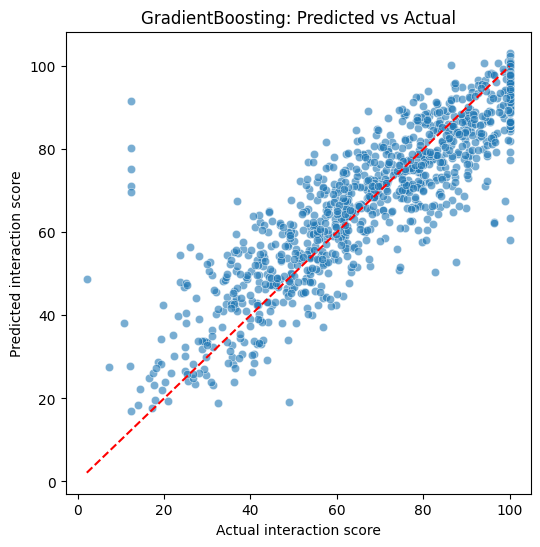

In [50]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred_final, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)
plt.xlabel("Actual interaction score")
plt.ylabel("Predicted interaction score")
plt.title(f"{final_model_name}: Predicted vs Actual")
plt.show()

To visualize predictive quality, we compare the model’s predicted interaction scores with the true test-set values.
Departures from diagonal reference line indicate over or under-prediction on individual cases.

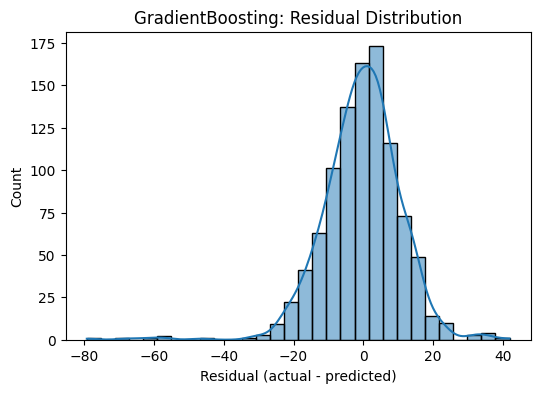

In [51]:
residuals_final = y_test - y_pred_final

plt.figure(figsize=(6, 4))
sns.histplot(residuals_final, bins=30, kde=True)
plt.xlabel("Residual (actual - predicted)")
plt.title(f"{final_model_name}: Residual Distribution")
plt.show()

Residuals are the difference between actual and predicted interaction scores. Plotting their distribution helps assess whether the model errors are centered around zero and whether large deviations are common.

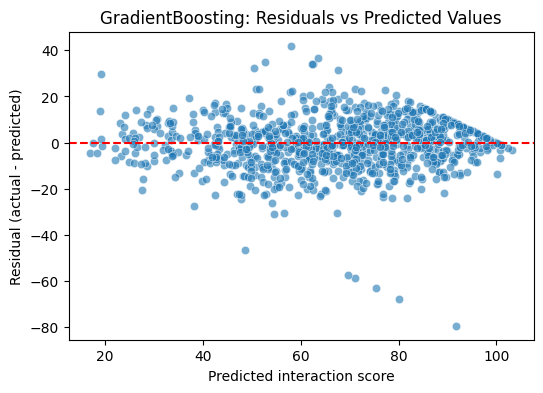

In [52]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred_final, y=residuals_final, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted interaction score")
plt.ylabel("Residual (actual - predicted)")
plt.title(f"{final_model_name}: Residuals vs Predicted Values")
plt.show()

We also plot residuals against predicted values to check for systematic error patterns. 
A random scatter around zero suggests that the model errors are relatively stable and not strongly structured.

# Permutation feature importance

To understand which variables contribute most to the final model’s predictions, we use permutation feature importance on the test set.
This method measures how much model performance decreases when the values of a feature are randomly shuffled. Larger importance values indicate that the model relies strongly on that variable.
This is particularly useful in this project, which is not only concerned with prediction accuracy but also with identifying the main drivers of interaction quality.

In [53]:
perm_importance = permutation_importance(final_pipeline,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1)

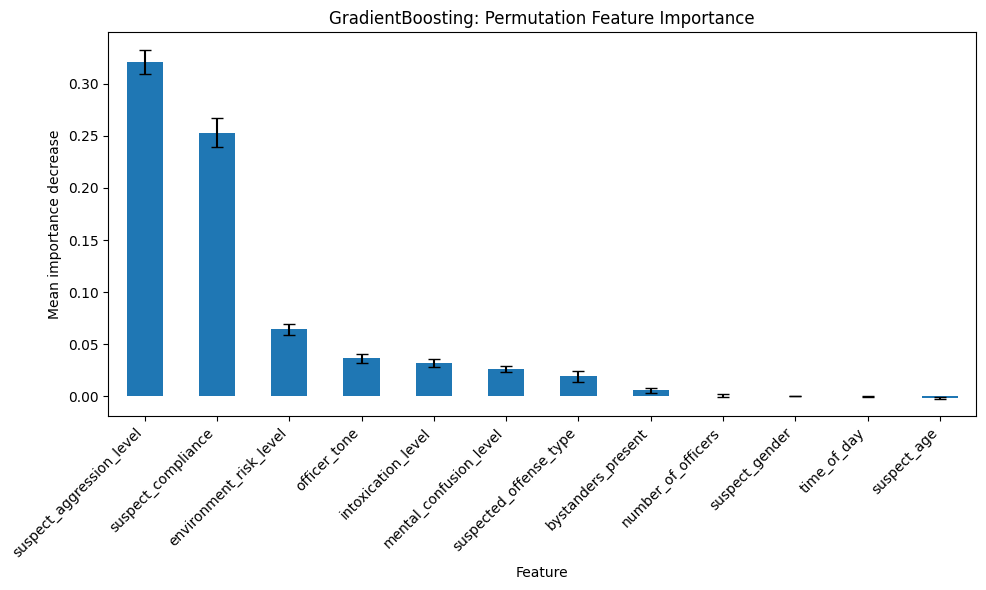

,importance
suspect_aggression_level,0.320909
suspect_compliance,0.253188
environment_risk_level,0.064438
officer_tone,0.036243
intoxication_level,0.031429
mental_confusion_level,0.026323
suspected_offense_type,0.018922
bystanders_present,0.005457
number_of_officers,0.000593
suspect_gender,0.000056


In [54]:
importances = pd.Series(perm_importance.importances_mean,
    index=X_test.columns).sort_values(ascending=False)

importance_std = pd.Series(perm_importance.importances_std,
    index=X_test.columns).loc[importances.index]

plt.figure(figsize=(10, 6))
importances.head(15).plot(kind="bar",
    yerr=importance_std.head(15),
    capsize=4)

plt.title(f"{final_model_name}: Permutation Feature Importance")
plt.ylabel("Mean importance decrease")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(importances.to_frame("importance"))

In [55]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [56]:
top_features = ["suspect_aggression_level",
    "suspect_compliance",
    "environment_risk_level"]

# Partial dependence + ICE plots:

After identifying the most influential variables, we use partial dependence and individual conditional expectation (ICE) plots to visualize how the predicted interaction score changes as these variables vary.

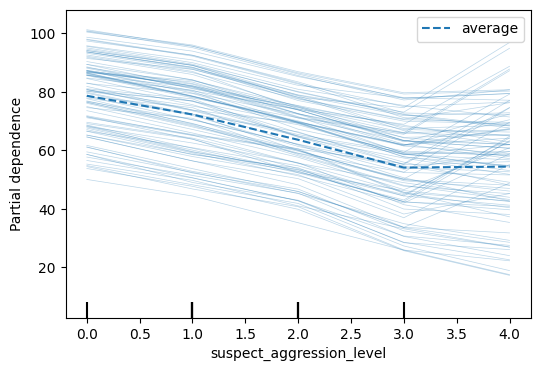

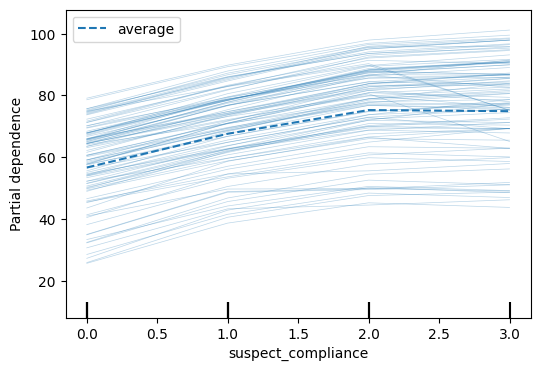

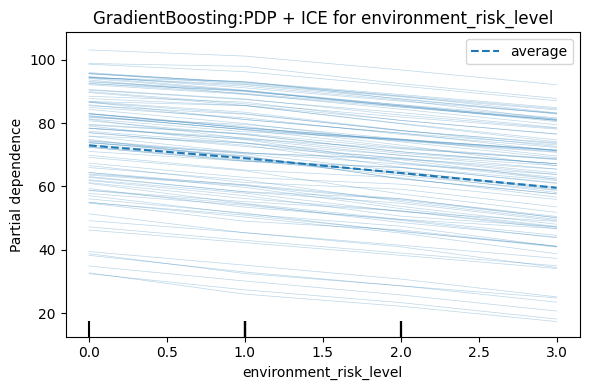

In [57]:
for feature in top_features:
    fig, ax = plt.subplots(figsize=(6,4))

    PartialDependenceDisplay.from_estimator(final_pipeline,
        X_test,
        features=[feature],
        kind="both",
        subsample = 100,
        random_state = 42,
        ax = ax)

plt.title(f"{final_model_name}:PDP + ICE for {feature}")
plt.tight_layout()
plt.show()   

To assess whether the final model generalizes appropriately, we inspect learning behavior across increasing training sizes.

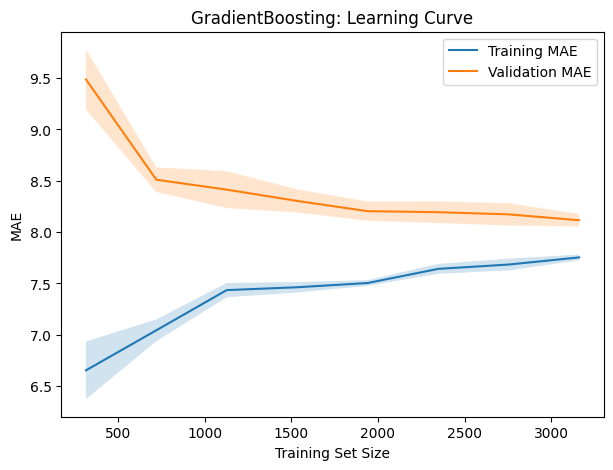

In [58]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(final_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_mean_absolute_error",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1,
    random_state=42)

train_mae_curve = -train_scores
val_mae_curve = -val_scores

train_mae_mean = train_mae_curve.mean(axis=1)
train_mae_std = train_mae_curve.std(axis=1)

val_mae_mean = val_mae_curve.mean(axis=1)
val_mae_std = val_mae_curve.std(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_mae_mean, label="Training MAE")
plt.plot(train_sizes, val_mae_mean, label="Validation MAE")

plt.fill_between(train_sizes,
    train_mae_mean - train_mae_std,
    train_mae_mean + train_mae_std,
    alpha=0.2)

plt.fill_between(train_sizes,
    val_mae_mean - val_mae_std,
    val_mae_mean + val_mae_std,
    alpha=0.2)

plt.xlabel("Training Set Size")
plt.ylabel("MAE")
plt.title(f"{final_model_name}: Learning Curve")
plt.legend()
plt.show()

In [59]:
y_pred_train = final_pipeline.predict(X_train)

comparison_metrics = pd.DataFrame({
    "set": ["train", "test"],
    "MAE": [mean_absolute_error(y_train, y_pred_train),
            mean_absolute_error(y_test, y_pred_final)],
    
    "RMSE": [np.sqrt(mean_squared_error(y_train, y_pred_train)),
             np.sqrt(mean_squared_error(y_test, y_pred_final))],
    "R2": [r2_score(y_train, y_pred_train),
           r2_score(y_test, y_pred_final)]})

display(comparison_metrics)

,set,MAE,RMSE,R2
0,train,7.786353,10.727569,0.762782
1,test,8.190501,11.170232,0.746409


In [60]:
import joblib
joblib.dump(final_pipeline, "eye2ai_final_pipeline.pkl")

['eye2ai_final_pipeline.pkl']

This notebook developed a supervised regression pipeline for predicting `interaction_score` from features observable before or during a police–civilian interaction. After data cleaning, feature grouping, and type-specific preprocessing, a GradientBoostingRegressor was selected through randomized search and achieved a test MAE of 8.19 and R² of 0.75.

Three post-interaction features: `force_used_level`, `interaction_duration_minutes`, and `officer_deescalation_attempts`, were excluded to keep the pipeline relevant to a real-time support context. This makes the metrics more honest, at the cost of some predictive accuracy.

Permutation importance showed that `suspect_aggression_level` and `suspect_compliance` were the dominant predictors, with demographic variables contributing almost nothing. This suggests interaction quality is driven by behavioral dynamics rather than subject characteristics. As the dataset is synthetic, these results should be treated as a proof-of-concept baseline rather than deployment-ready findings.